In [49]:
import os
import shutil
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from skimage.feature import hog
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import random
from imutils.object_detection import non_max_suppression
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as patches

#### Load data

In [ ]:
data_path = "Data/brain_tumor_dataset"

yes_path = os.path.join(data_path, "yes")
no_path = os.path.join(data_path, "no")

#### Split train/test folders

In [3]:
train_path = os.path.join(data_path, "../train")
test_path  = os.path.join(data_path, "../test")


for folder in [train_path, test_path]:
    os.makedirs(os.path.join(folder, "yes"), exist_ok=True)
    os.makedirs(os.path.join(folder, "no"), exist_ok=True)

yes_files = os.listdir(yes_path)
yes_train, yes_test = train_test_split(yes_files, test_size=0.2, random_state=42)


for f in yes_train:
    shutil.copy(os.path.join(yes_path, f), os.path.join(train_path, "yes", f))
for f in yes_test:
    shutil.copy(os.path.join(yes_path, f), os.path.join(test_path, "yes", f))


no_files = os.listdir(no_path)
no_train, no_test = train_test_split(no_files, test_size=0.2, random_state=42)


for f in no_train:
    shutil.copy(os.path.join(no_path, f), os.path.join(train_path, "no", f))
for f in no_test:
    shutil.copy(os.path.join(no_path, f), os.path.join(test_path, "no", f))

print("Dataset splitted successfully!")
print(f"Train YES: {len(yes_train)}, Train NO: {len(no_train)}")
print(f"Test YES: {len(yes_test)}, Test NO: {len(no_test)}")

Dataset splitted successfully!
Train YES: 124, Train NO: 78
Test YES: 31, Test NO: 20


#### Resize + Label

In [5]:
data_path = "Data"
train_path = os.path.join(data_path, "train")
test_path  = os.path.join(data_path, "test")

size = (128,128)  

def load_images_from_folder(folder):
    images = []
    labels = []
    for category in ["yes", "no"]:
        cat_path = os.path.join(folder, category)
        for file in os.listdir(cat_path):
            img_path = os.path.join(cat_path, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, size)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(gray)
            labels.append(1 if category=="yes" else 0)
    return images, labels


train_images, train_labels = load_images_from_folder(train_path)

test_images, test_labels = load_images_from_folder(test_path)

print(f"Train: {len(train_images)} images, Test: {len(test_images)} images")

Train: 202 images, Test: 51 images


#### Show samples

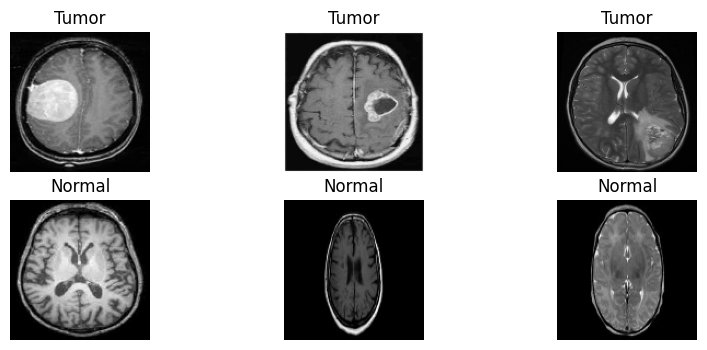

In [ ]:
plt.figure(figsize=(10,4))

count_yes = 0
count_no = 0
i = 0

while i < len(train_images) and (count_yes < 3 or count_no < 3):
    if train_labels[i] == 1 and count_yes < 3:
        plt.subplot(2,3,count_yes+1)
        plt.imshow(train_images[i], cmap='gray')
        plt.title("Tumor")
        plt.axis("off")
        count_yes += 1
    elif train_labels[i] == 0 and count_no < 3:
        plt.subplot(2,3,3+count_no+1)
        plt.imshow(train_images[i], cmap='gray')
        plt.title("Normal")
        plt.axis("off")
        count_no += 1
    i += 1

plt.show()

#### Extract HOG

In [ ]:
orientations = 9
pixels_per_cell = (8,8)
cells_per_block = (2,2)
block_norm = 'L2-Hys'

# Extract HOG features for train
train_features = []
for img in train_images:
    feat = hog(img,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm=block_norm)
    train_features.append(feat)

train_features = np.array(train_features)
train_labels_np = np.array(train_labels)

print(f"Train features shape: {train_features.shape}")

Train features shape: (202, 8100)


In [ ]:
# Extract HOG features for test
test_features = []
for img in test_images:
    feat = hog(img,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm=block_norm)
    test_features.append(feat)

test_features = np.array(test_features)
test_labels_np = np.array(test_labels)

print(f"Test features shape: {test_features.shape}")

Test features shape: (51, 8100)


#### Train classifier --> LinearSVC

In [12]:
clf = LinearSVC(max_iter=10000, random_state=42)

clf.fit(train_features, train_labels_np)

test_pred = clf.predict(test_features)

acc = accuracy_score(test_labels_np, test_pred)
cm = confusion_matrix(test_labels_np, test_pred)
report = classification_report(test_labels_np, test_pred)

print(f"Test Accuracy: {acc*100:.2f}%")
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(report)

Test Accuracy: 88.24%
Confusion Matrix:
[[16  4]
 [ 2 29]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.88      0.94      0.91        31

    accuracy                           0.88        51
   macro avg       0.88      0.87      0.87        51
weighted avg       0.88      0.88      0.88        51



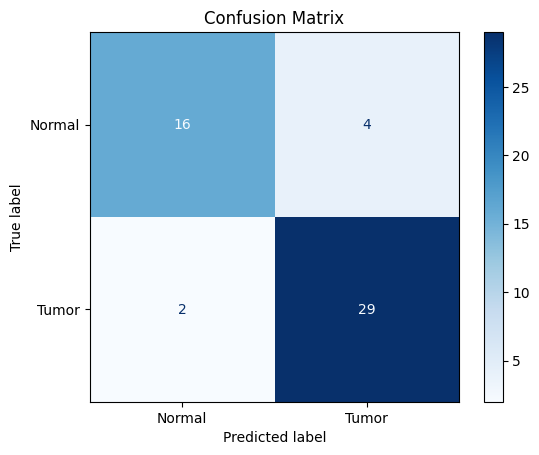

In [50]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal","Tumor"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

#### Sliding Window detection

In [ ]:
def sliding_window(image, step_size, window_size):
    """
    Generator function to slide a window across the image.
    - image: grayscale image
    - step_size: number of pixels to move the window at each step
    - window_size: (width, height) of the window
    """
    for y in range(0, image.shape[0] - window_size[1] + 1, step_size):
        for x in range(0, image.shape[1] - window_size[0] + 1, step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

In [ ]:
def draw_boxes(image, boxes):
    """
    Draw rectangles on the image
    - image: RGB or grayscale image
    - boxes: list of tuples (x, y, width, height)
    """
    fig, ax = plt.subplots(1)
    if len(image.shape)==2:  
        ax.imshow(image, cmap='gray')
    else:
        ax.imshow(image)

    for (x, y, w, h) in boxes:
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

    plt.show()

Processing yes image: Y116.JPG
  Detections after NMS: 2


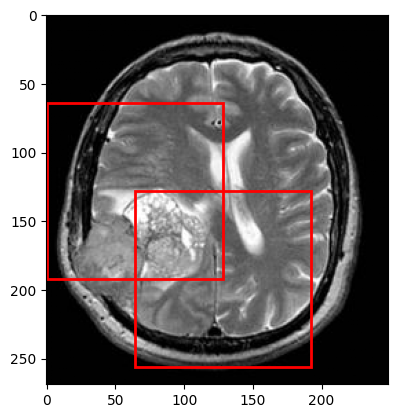

Processing no image: 13 no.jpg
  Detections after NMS: 0


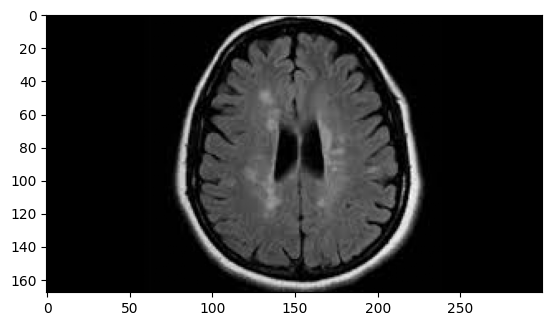

In [46]:
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys'
)

scaler = StandardScaler()
scaler.fit(train_features)

test_path = "Data/test"
folders = ["yes", "no"]
threshold = 2.0
step_size = 64
window_size = (128, 128)

for folder in folders:
    folder_path = os.path.join(test_path, folder)
    img_name = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img_gray.shape[0] < window_size[1] or img_gray.shape[1] < window_size[0]:
        print(f"Image too small, skipping.")
        continue

    print(f"Processing {folder} image: {img_name}")

    detections = []
    for (x, y, window) in sliding_window(img_gray, step_size, window_size):
        if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
            continue

        feat = hog(window, **HOG_PARAMS).reshape(1, -1)
        feat = scaler.transform(feat)

        score = clf.decision_function(feat)[0]
        if score > threshold:
            detections.append((x, y, window_size[0], window_size[1]))

    if detections:
        boxes = np.array([[x, y, x+w, y+h] for (x,y,w,h) in detections])
        pick  = non_max_suppression(boxes, probs=None, overlapThresh=0.3)
        detections = [(x1, y1, x2-x1, y2-y1) for (x1,y1,x2,y2) in pick]

    print(f"  Detections after NMS: {len(detections)}")
    draw_boxes(img_gray, detections)